In [12]:
import pandas as pd
import seaborn as sns

In [2]:
data = pd.read_csv("../example_data/transformed_data.csv")

In [3]:
data.shape

(17610, 22)

In [4]:
data.head()

,filehash,winner,player_1_race,player_2_race,seconds,food_made_diff,food_used_diff,minerals_collection_rate_diff,minerals_lost_diff,minerals_lost_army_diff,...,minerals_used_current_economy_diff,vespene_collection_rate_diff,vespene_lost_diff,vespene_lost_army_diff,vespene_used_current_diff,vespene_used_current_army_diff,vespene_used_current_economy_diff,vespene_used_current_technology_diff,workers_active_count_diff,sample
0,728e1e193129349c175d1bd8f2598cbeb0875b409939a7...,1,Terran,Terran,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train
1,728e1e193129349c175d1bd8f2598cbeb0875b409939a7...,1,Terran,Terran,10.0,0.0,0.0,-42.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train
2,728e1e193129349c175d1bd8f2598cbeb0875b409939a7...,1,Terran,Terran,20.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train
3,728e1e193129349c175d1bd8f2598cbeb0875b409939a7...,1,Terran,Terran,30.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train
4,728e1e193129349c175d1bd8f2598cbeb0875b409939a7...,1,Terran,Terran,40.0,0.0,0.0,56.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,train


In [5]:
data["filehash"].nunique()

171

In [37]:
def plot_1_way_feature(data: pd.DataFrame, feature: str):
    subset = data[["winner", feature]].copy()
    subset[feature + "_binned"] = pd.qcut(subset[feature], q=10, duplicates="drop")
    grouped_val = subset.groupby(feature + "_binned")["winner"].mean()
    sns.pointplot(x=grouped_val.index, y=grouped_val.values)
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.show()

/var/folders/hl/1wwnp4rj1091jv34r4wfvckm0000gn/T/ipykernel_26417/128896621.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_val = subset.groupby(feature + "_binned")["winner"].mean()


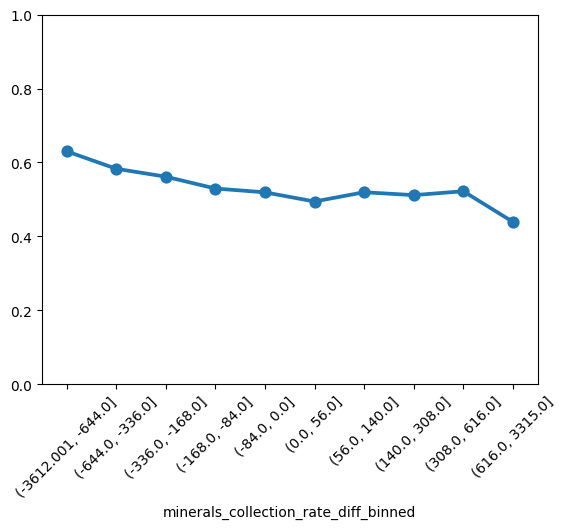

In [38]:
plot_1_way_feature(data, "minerals_collection_rate_diff")

In [11]:
data["minerals_lost_diff"].describe()

count    17610.000000
mean       275.579443
std       1889.127606
min     -16187.000000
25%        -75.000000
50%          0.000000
75%        275.000000
max      14590.000000
Name: minerals_lost_diff, dtype: float64

In [14]:
data["minerals_lost_diff_binned"] = pd.qcut(data["minerals_lost_diff"], q=10, duplicates="drop")

In [17]:
grouped_val = data.groupby("minerals_lost_diff_binned")["winner"].mean()

/var/folders/hl/1wwnp4rj1091jv34r4wfvckm0000gn/T/ipykernel_26417/2219438461.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_val = data.groupby("minerals_lost_diff_binned")["winner"].mean()


In [27]:
import matplotlib.pyplot as plt

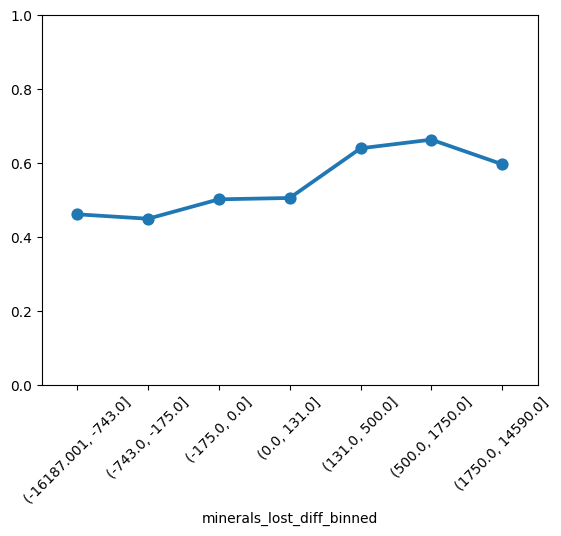